In [ ]:
OPENAI_API_KEY = ""

In [2]:
import json
import time
from typing import TypedDict, Optional, List

from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

In [3]:
llm_fast = ChatOpenAI(model="gpt-5-nano", temperature=0, api_key=OPENAI_API_KEY)
llm_slow = ChatOpenAI(model="gpt-5-nano", temperature=0.2, api_key=OPENAI_API_KEY)

## Test 2

In [4]:
# Load protocol JSON
with open("protocol.json", "r") as f:
    PROTOCOL = json.load(f)

NUM_TOPICS = len(PROTOCOL["topics"])


In [5]:
class InterviewState(TypedDict):
    # Topic context
    topic: str
    topic_objective: str
    topic_transcript: str

    # Latest turn
    interviewee_response: str

    # Evaluator output
    decision: Optional[str]                 # PROBE | PROBE_IF_TIME | MOVE_ON
    probing_type: Optional[str]
    evaluator_rationale: Optional[str]

    # Global constraints
    remaining_time: int                     # seconds
    estimated_probe_time: int               # seconds

    # Orchestrator output
    final_decision: Optional[str]            # PROBE | MOVE_ON
    orchestrator_rationale: Optional[str]

    # Generator output
    follow_up_question: Optional[str]


In [6]:
topic_monitor_prompt = ChatPromptTemplate.from_template("""
You are a semi-structured interview response evaluator.

Interview topic:
"{topic}"

Topic objective:
"{topic_objective}"

Transcript so far for this topic:
"{topic_transcript}"

Latest interviewee response:
"{interviewee_response}"

Assumptions:
- In principle, any response can be further probed.
- However, interview time is limited.
- Your task is to decide whether additional probing is NECESSARY,
  OPTIONAL, or UNNECESSARY to meet the topic objective.

Decision criteria:
- NECESSARY: Key aspects of the topic objective are missing, unclear,
  or weakly supported.
- OPTIONAL: The objective is mostly met, but further probing could
  yield richer insights if time permits.
- UNNECESSARY: The response sufficiently addresses the topic objective;
  further probing would likely yield diminishing returns.

Your task:
1. Decide whether the interviewer should PROBE, PROBE_IF_TIME, or MOVE_ON.
2. If probing is recommended, identify the MOST SALIENT probing type:

- Clarification
- Probing assumptions
- Probing reasons and evidences
- Probing implications and consequences
- Probing alternative viewpoints and perspectives
- None

3. Provide a brief rationale (1–2 sentences).

Output format (strict JSON):

{
  "decision": "<PROBE | PROBE_IF_TIME | MOVE_ON>",
  "probing_type": "<one from the list above or None>",
  "rationale": "<concise justification>"
}
""")


In [7]:
topic_monitor_prompt = ChatPromptTemplate.from_template("""
You are a semi-structured interview response evaluator.

Interview topic:
"{topic}"

Topic objective:
"{topic_objective}"

Transcript so far:
"{topic_transcript}"

Latest interviewee response:
"{interviewee_response}"

Decide whether further probing is:
- NECESSARY
- OPTIONAL
- UNNECESSARY

Map these to:
- NECESSARY → PROBE
- OPTIONAL → PROBE_IF_TIME
- UNNECESSARY → MOVE_ON

If probing is recommended, choose ONE probing type:
- Clarification
- Probing assumptions
- Probing reasons and evidences
- Probing implications and consequences
- Probing alternative viewpoints and perspectives
- None

Output STRICT JSON:
{{
  "decision": "<PROBE | PROBE_IF_TIME | MOVE_ON>",
  "probing_type": "<one from list or None>",
  "rationale": "<1–2 sentence justification>"
}}
""")


In [8]:
orchestrator_prompt = ChatPromptTemplate.from_template("""
You manage interview time across multiple topics.

Evaluator recommendation: "{decision}"
Evaluator rationale: "{evaluator_rationale}"
Remaining interview time (seconds): {remaining_time}
Estimated time for one probe (seconds): {estimated_probe_time}

Decision rules:
- If remaining time is insufficient → MOVE_ON
- If recommendation is PROBE and time allows → PROBE
- If recommendation is PROBE_IF_TIME → probe only if time comfortably allows
- Otherwise → MOVE_ON

Output STRICT JSON:
{{
  "final_decision": "<PROBE | MOVE_ON>",
  "rationale": "<brief justification>"
}}
""")


In [9]:
follow_up_prompt = ChatPromptTemplate.from_template("""
You are a qualitative interviewer.

Topic:
"{topic}"

Transcript so far:
"{topic_transcript}"

Latest interviewee response:
"{latest_response}"

Probing type:
"{probing_type}"

Ask ONE neutral, focused follow-up question.
Do not introduce a new topic.

Output ONLY the question.
""")


In [10]:
def topic_response_evaluator(state: InterviewState):
    response = llm_fast.invoke(
        topic_monitor_prompt.format(**state)
    )
    parsed = json.loads(response.content)

    return {
        "decision": parsed["decision"],
        "probing_type": parsed["probing_type"],
        "evaluator_rationale": parsed["rationale"]
    }


In [11]:
def orchestrator_agent(state: InterviewState):
    # Hard guardrail
    if state["remaining_time"] <= 0:
        return {
            "final_decision": "MOVE_ON",
            "orchestrator_rationale": "No remaining interview time."
        }

    response = llm_fast.invoke(
        orchestrator_prompt.format(
            decision=state["decision"],
            evaluator_rationale=state["evaluator_rationale"],
            remaining_time=state["remaining_time"],
            estimated_probe_time=state["estimated_probe_time"]
        )
    )

    parsed = json.loads(response.content)

    return {
        "final_decision": parsed["final_decision"],
        "orchestrator_rationale": parsed["rationale"]
    }


In [12]:
def decision_router(state: InterviewState):
    if state["final_decision"] == "PROBE":
        return "follow_up"
    return "next_topic"


In [13]:
def update_topic_transcript(state: InterviewState):
    updated_transcript = (
        state["topic_transcript"]
        + f"\nInterviewee: {state['interviewee_response']}"
    )

    return {
        "topic_transcript": updated_transcript,
        "remaining_time": state["remaining_time"] - state["estimated_probe_time"]
    }


In [14]:
def follow_up_question_agent(state: InterviewState):
    response = llm_fast.invoke(
        follow_up_prompt.format(
            topic=state["topic"],
            topic_transcript=state["topic_transcript"],
            latest_response=state["interviewee_response"],
            probing_type=state["probing_type"]
        )
    )

    return {
        "follow_up_question": response.content.strip()
    }


In [15]:
graph = StateGraph(InterviewState)

graph.add_node("evaluator", topic_response_evaluator)
graph.add_node("orchestrator", orchestrator_agent)
graph.add_node("follow_up", follow_up_question_agent)
graph.add_node("update_transcript", update_topic_transcript)

graph.set_entry_point("evaluator")

graph.add_edge("evaluator", "orchestrator")

graph.add_conditional_edges(
    "orchestrator",
    decision_router,
    {
        "follow_up": "follow_up",
        "next_topic": END
    }
)

graph.add_edge("follow_up", "update_transcript")
graph.add_edge("update_transcript", END)

interview_graph = graph.compile()


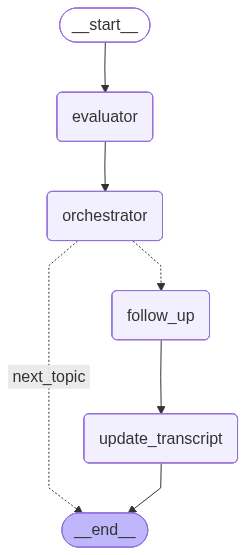

In [16]:
interview_graph

In [17]:
state = {
    "topic": "Adoption of AI tools at work",
    "topic_objective": "Understand why and how AI tools are used in daily work",
    "topic_transcript": "Interviewee: I’ve started using AI tools more often.",
    "interviewee_response": "I find them helpful when I’m short on time.",
    "remaining_time": 90,
    "estimated_probe_time": 30
}

state = interview_graph.invoke(state)


In [18]:
state


{'topic': 'Adoption of AI tools at work',
 'topic_objective': 'Understand why and how AI tools are used in daily work',
 'topic_transcript': 'Interviewee: I’ve started using AI tools more often.\nInterviewee: I find them helpful when I’m short on time.',
 'interviewee_response': 'I find them helpful when I’m short on time.',
 'decision': 'PROBE',
 'probing_type': 'Probing reasons and evidences',
 'evaluator_rationale': 'The response indicates time-saving benefits but lacks specifics on tasks and measurable impact; probing reasons and evidences will elicit concrete examples of how and why AI is used day-to-day.',
 'remaining_time': 60,
 'estimated_probe_time': 30,
 'final_decision': 'PROBE',
 'orchestrator_rationale': 'Recommendation is PROBE and there are enough seconds left to perform at least one probe (90s remaining, probe ~30s). Probing will elicit concrete, day-to-day AI usage examples, tasks, and measurable impact beyond stated benefits.',
 'follow_up_question': 'Can you describe